In [5]:
import pandas as pd

power_df = pd.read_csv(
    r"D:\Phase_Identification_Project\data\active_power_30d.csv"
)

reactive_df = pd.read_csv(
    r"D:\Phase_Identification_Project\data\reactive_power_30d.csv"
)

voltage_df = pd.read_csv(
    r"D:\Phase_Identification_Project\data\voltage_timeseries_30d.csv"
)

phase_df = pd.read_csv(
    r"D:\Phase_Identification_Project\data\ground_truth_phases.csv"
)

map_df = pd.read_csv(
    r"D:\Phase_Identification_Project\data\load_node_map.csv"
)

print("POWER")
print(power_df.shape)
print(power_df.columns[:10])

print("\nREACTIVE")
print(reactive_df.shape)

print("\nVOLTAGE")
print(voltage_df.shape)

print("\nPHASE")
print(phase_df.shape)
print(phase_df.columns)

print("\nLOAD MAP")
print(map_df.shape)
print(map_df.columns)

phase_df.head()

POWER
(35040, 91)
Index(['S1a', 'S2b', 'S4c', 'S5c', 'S6c', 'S7a', 'S9a', 'S10a', 'S11a',
       'S12b'],
      dtype='str')

REACTIVE
(35040, 91)

VOLTAGE
(35040, 91)

PHASE
(91, 2)
Index(['load_name', 'true_phase'], dtype='str')

LOAD MAP
(91, 2)
Index(['load_name', 'node'], dtype='str')


,load_name,true_phase
0,S1a,A
1,S2b,B
2,S4c,C
3,S5c,C
4,S6c,C


In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")


power_df = pd.read_csv(
    r"D:\Phase_Identification_Project\data\active_power_30d.csv"
)

reactive_df = pd.read_csv(
    r"D:\Phase_Identification_Project\data\reactive_power_30d.csv"
)

voltage_df = pd.read_csv(
    r"D:\Phase_Identification_Project\data\voltage_timeseries_30d.csv"
)

phase_df = pd.read_csv(
    r"D:\Phase_Identification_Project\data\ground_truth_phases.csv"
)

map_df = pd.read_csv(
    r"D:\Phase_Identification_Project\data\load_node_map.csv"
)

print(power_df.shape)
print(reactive_df.shape)
print(voltage_df.shape)

(35040, 91)
(35040, 91)
(35040, 91)


In [7]:
print("POWER")

print(power_df.isnull().sum().sum())

print("REACTIVE")

print(reactive_df.isnull().sum().sum())

print("VOLTAGE")

print(voltage_df.isnull().sum().sum())

POWER
0
REACTIVE
0
VOLTAGE
0


In [8]:
summary = pd.DataFrame({
    "Mean Voltage": voltage_df.mean(),
    "Std Voltage": voltage_df.std(),
    "Mean P": power_df.mean(),
    "Mean Q": reactive_df.mean()
})

summary.head()

,Mean Voltage,Std Voltage,Mean P,Mean Q
S1a,1.021590,0.002721,40.0,20.0
S2b,1.029239,0.003171,20.0,10.0
S4c,1.022505,0.002844,40.0,20.0
S5c,1.021866,0.002840,20.0,10.0
S6c,1.021312,0.002838,40.0,20.0


The average voltage profile was computed by averaging voltage measurements across all 91 loads at each timestep. The voltage remains within a narrow range around 1 pu throughout the 30-day simulation, indicating a stable feeder and physically realistic operating conditions.

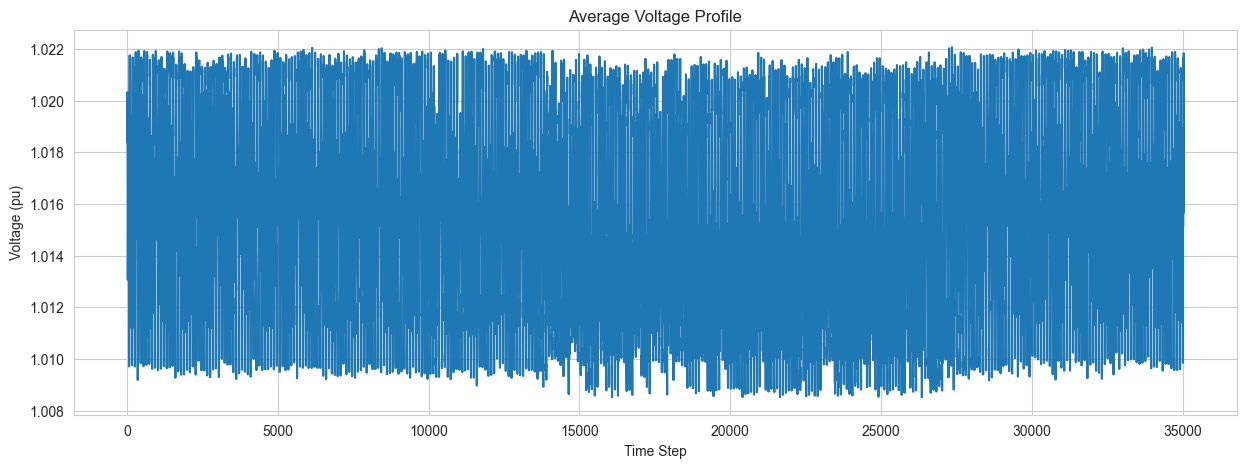

In [9]:
avg_voltage = voltage_df.mean(axis=1)

plt.figure(figsize=(15,5))

plt.plot(avg_voltage)

plt.title("Average Voltage Profile")

plt.xlabel("Time Step")

plt.ylabel("Voltage (pu)")

plt.show()

The average active power profile remains approximately constant over time, suggesting that the simulated load demands are largely stationary. This indicates that phase-identification performance will primarily depend on voltage relationships rather than large temporal variations in active power.

Most loads have constant demand values
during the simulation.

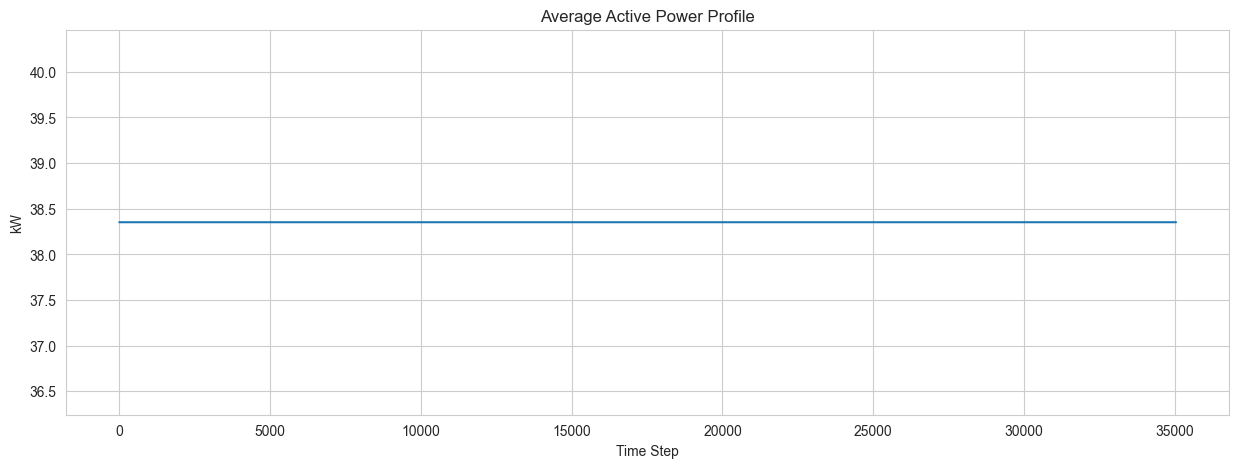

In [10]:
avg_power = power_df.mean(axis=1)

plt.figure(figsize=(15,5))

plt.plot(avg_power)

plt.title("Average Active Power Profile")

plt.xlabel("Time Step")

plt.ylabel("kW")

plt.show()

Reactive power remains relatively constant over the simulation horizon. This suggests that the feeder operates under stable reactive loading conditions and provides a controlled environment for evaluating phase-identification methods.


Voltage variation is not being driven
by rapidly changing reactive loads.

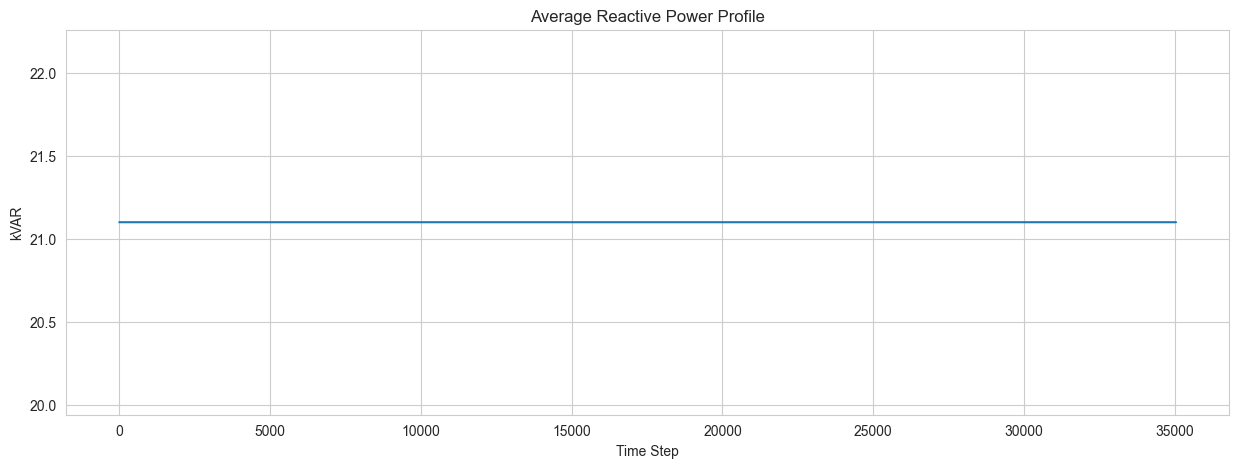

In [11]:
avg_reactive = reactive_df.mean(axis=1)

plt.figure(figsize=(15,5))

plt.plot(avg_reactive)

plt.title("Average Reactive Power Profile")

plt.xlabel("Time Step")

plt.ylabel("kVAR")

plt.show()

The voltage heatmap reveals clear differences in voltage magnitude across loads. Distinct voltage patterns are visible, suggesting that electrical proximity and phase connectivity influence voltage behavior. These observations motivate the use of correlation-based phase identification techniques.

I can immediately see:
Different voltage bands

For example:

Some loads:
0.98 - 1.00 pu
Others:
1.02 - 1.05 pu

This means loads do not experience identical voltages.
That is exactly what phase identification needs.

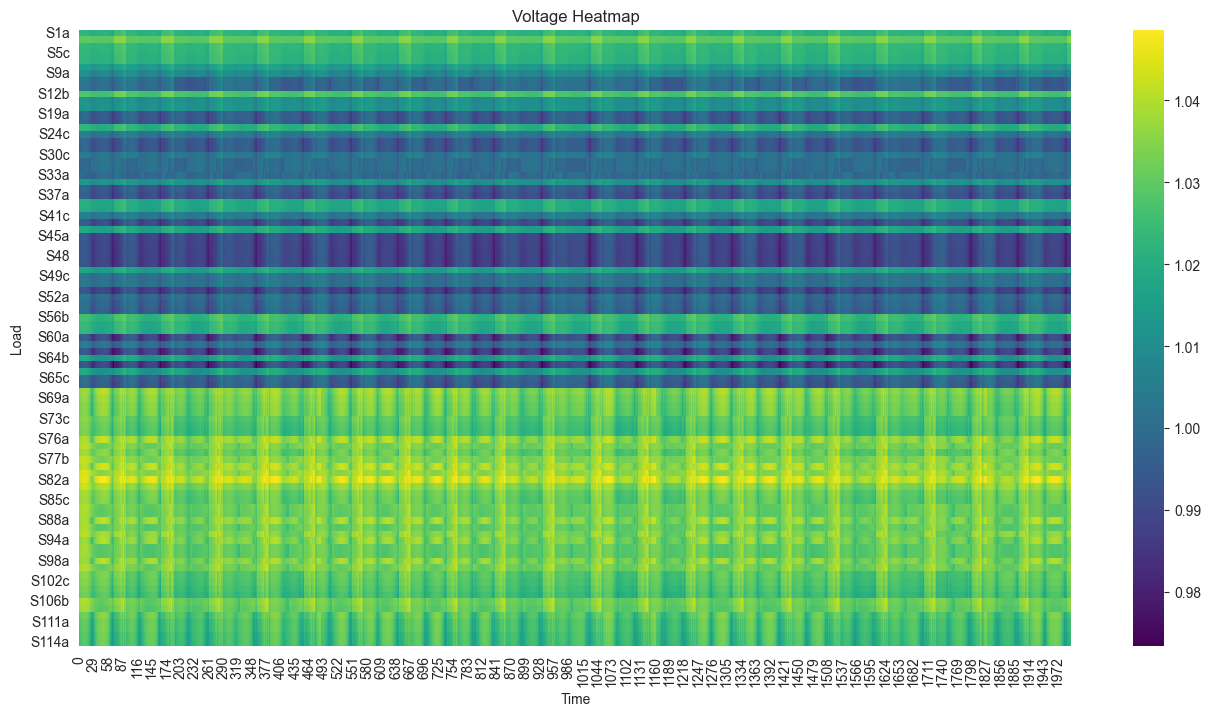

In [12]:
plt.figure(figsize=(16,8))

sns.heatmap(
    voltage_df.iloc[:2000].T,
    cmap="viridis"
)

plt.title("Voltage Heatmap")

plt.xlabel("Time")

plt.ylabel("Load")

plt.show()

The active power heatmap highlights significant variability among customer loads. Certain loads exhibit substantially higher power consumption than others, reflecting realistic feeder diversity and load heterogeneity.

Different loads consume different amounts of power.
Notice:
S48
is much brighter than others.
Meaning:
S48 is a high-demand customer.

What This Tells Us
Not all loads are equally important.
Some customers dominate feeder loading.

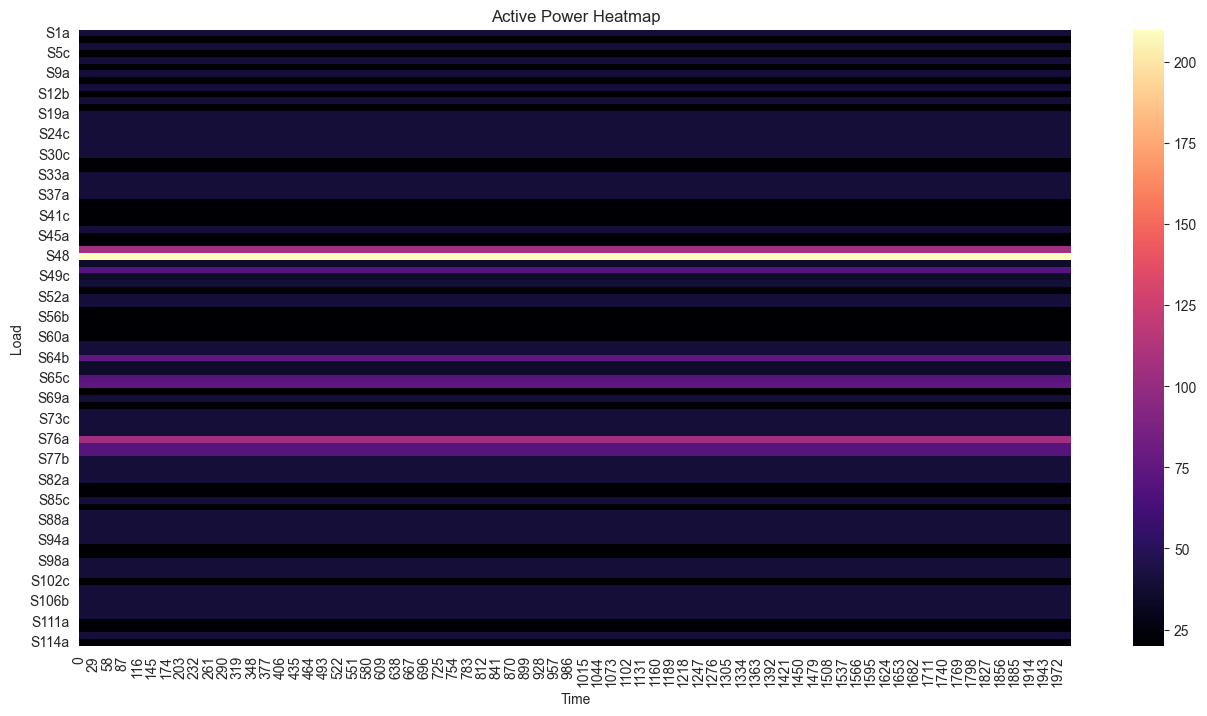

In [13]:
plt.figure(figsize=(16,8))

sns.heatmap(
    power_df.iloc[:2000].T,
    cmap="magma"
)

plt.title("Active Power Heatmap")

plt.xlabel("Time")

plt.ylabel("Load")

plt.show()

Reactive power consumption varies across customers, with a subset of loads exhibiting consistently higher reactive demand. This variation influences local voltage behavior and contributes to the electrical signatures used for phase identification.

Same interpretation.
You can see:
S48
S76a
have higher reactive demand.

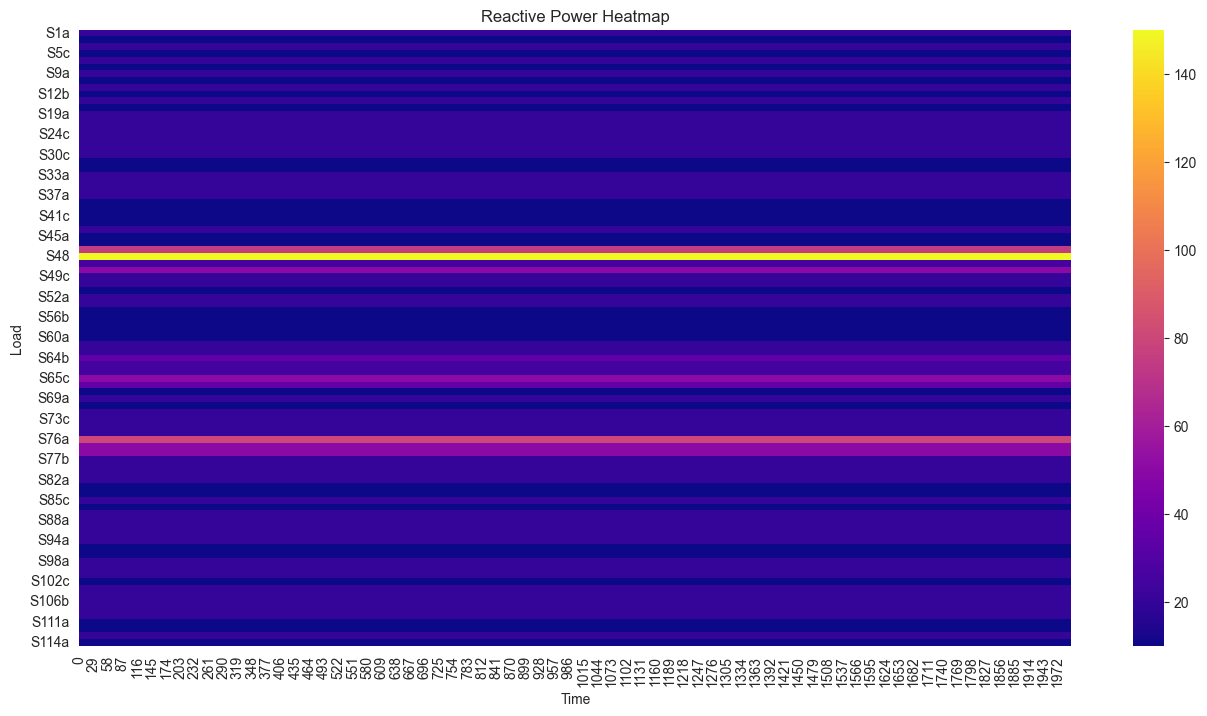

In [14]:
plt.figure(figsize=(16,8))

sns.heatmap(
    reactive_df.iloc[:2000].T,
    cmap="plasma"
)

plt.title("Reactive Power Heatmap")

plt.xlabel("Time")

plt.ylabel("Load")

plt.show()

The dataset contains 91 loads distributed across three phases. Although Phase A contains slightly more customers than Phases B and C, the class imbalance is moderate and should not significantly bias downstream classification models.

The classes are not perfectly balanced.
But they are not severely imbalanced either.
Why This Matters

If:
A = 80
B = 5
C = 6

then a classifier could cheat.

true_phase
A    40
C    28
B    23
Name: count, dtype: int64


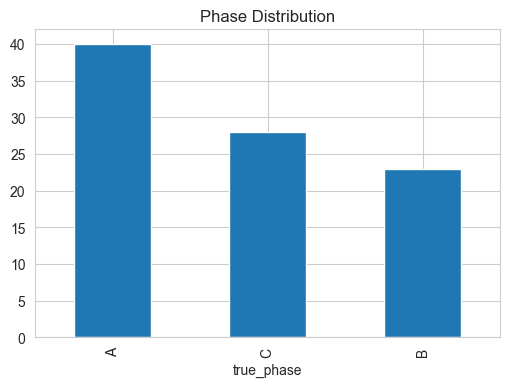

In [15]:
phase_counts = phase_df["true_phase"].value_counts()

print(phase_counts)

phase_counts.plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Phase Distribution")

plt.show()

Voltage Correlation Matrix

We calculate correlation between every pair of loads.
If two loads are on the same phase and electrically close, their voltage variations tend to move together


Every pixel represents:
Correlation between two loads
Values:
1.0   → perfectly correlated
0.7   → strongly correlated
0.3   → weakly correlated
0.0   → unrelated
Dark red:
Strong voltage similarity
Light colors:
Weak voltage similarity

Upper-left block
Lower-right block
These are groups of loads behaving similarly.
This is exactly what we hope to see.


The voltage correlation matrix reveals strong pairwise relationships among many loads. Several visually distinct high-correlation regions are observed, indicating that groups of customers experience similar voltage behavior. This suggests that voltage measurements contain structural information that may be exploited for phase identification.

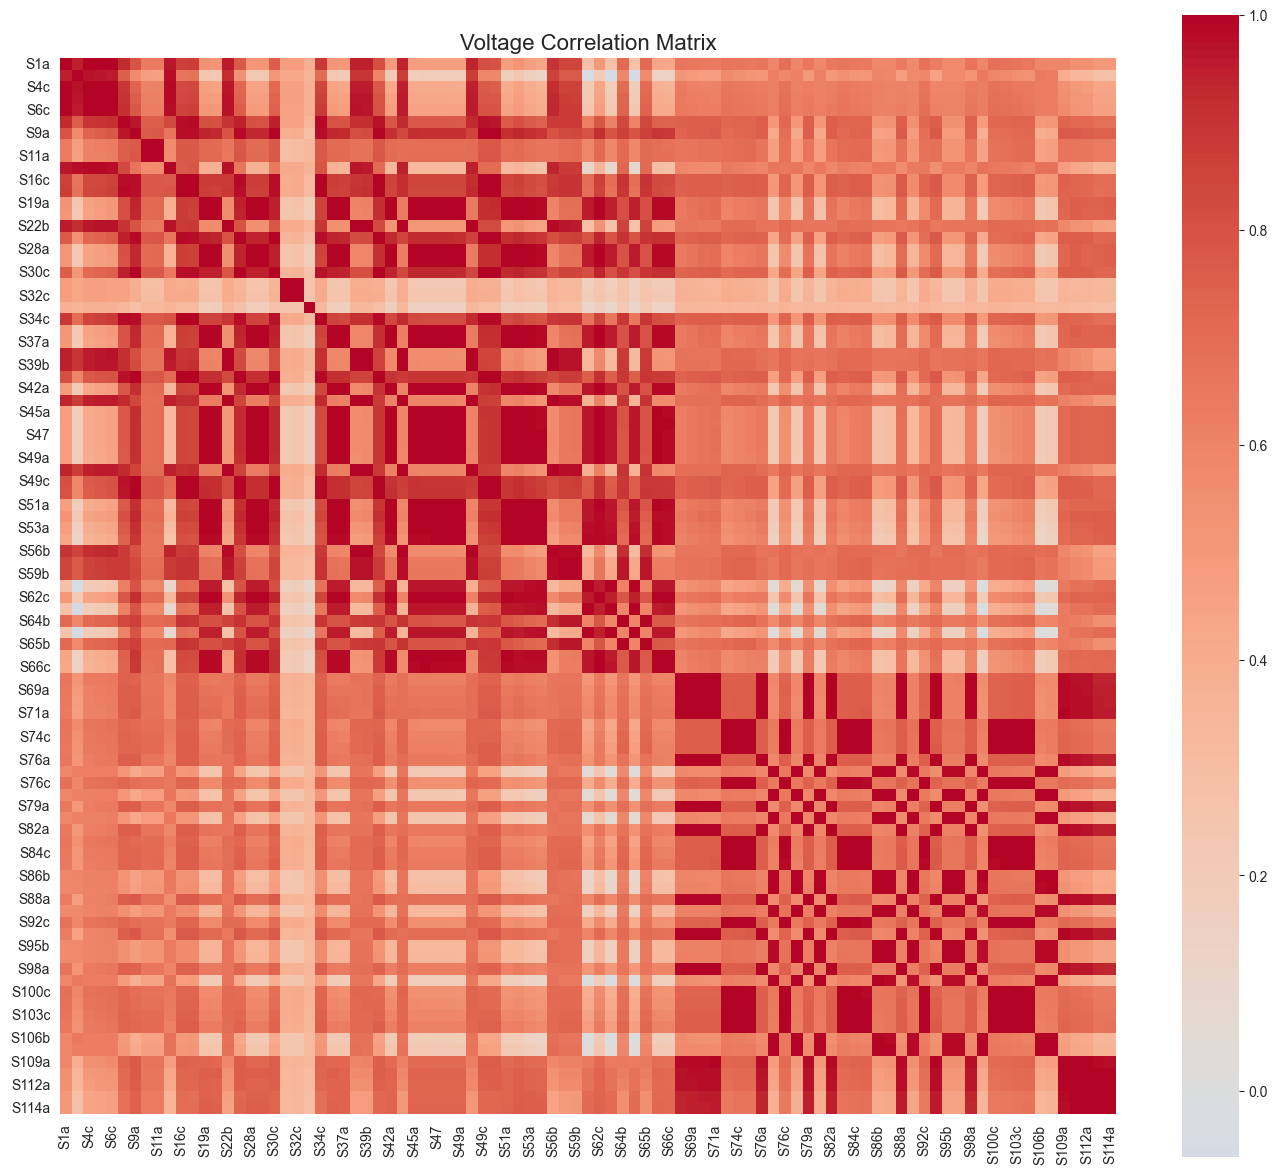

In [16]:
# =====================================================
# VOLTAGE CORRELATION MATRIX
# =====================================================

voltage_corr = voltage_df.corr()

plt.figure(figsize=(14,12))

sns.heatmap(
    voltage_corr,
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title(
    "Voltage Correlation Matrix",
    fontsize=16
)

plt.tight_layout()

plt.show()

Correlation Matrix Sorted by True Phase

If phase information exists:
A-A correlations → strong
B-B correlations → strong
C-C correlations → strong
creating three bright blocks.

We do see structure.
The matrix is not random.
However:
The three blocks are not perfectly separated.
Some cross-phase correlations are also strong.


If the blocks were perfectly separated:
Problem solved.
No need for ML.
The fact that:
Some information exists
but not perfectly is exactly why GNNs become useful.

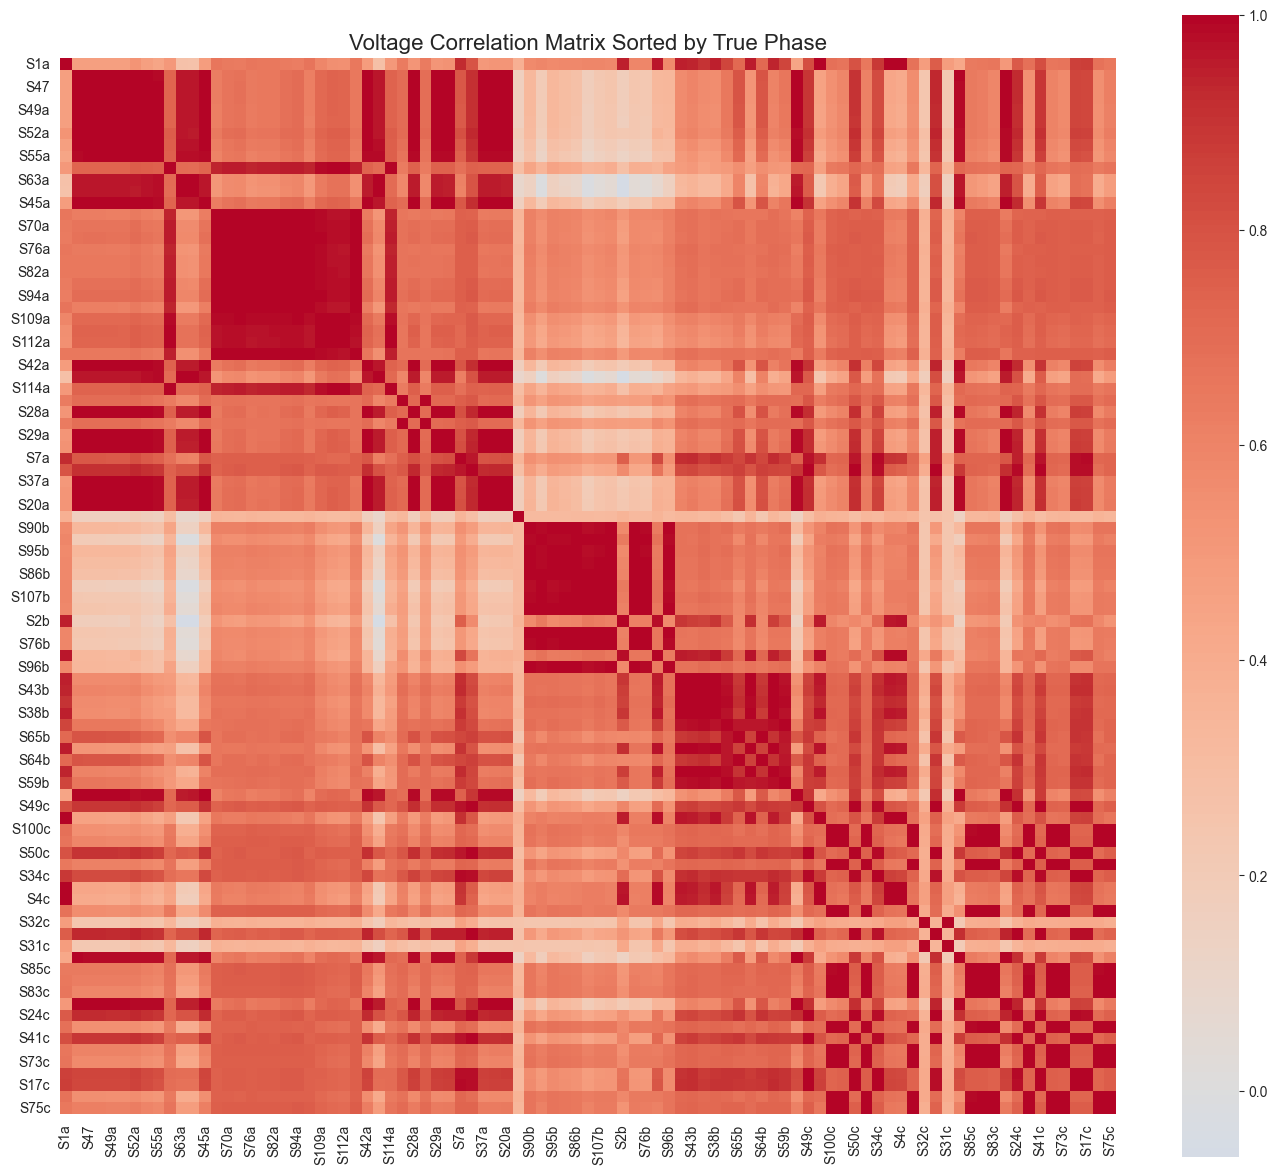

In [18]:
# =====================================================
# PHASE SORTED CORRELATION MATRIX
# =====================================================

phase_sorted = phase_df.sort_values(
    "true_phase"
)

ordered_loads = phase_sorted["load_name"]

corr_sorted = voltage_corr.loc[
    ordered_loads,
    ordered_loads
]

plt.figure(figsize=(14,12))

sns.heatmap(
    corr_sorted,
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title(
    "Voltage Correlation Matrix Sorted by True Phase",
    fontsize=16
)

plt.tight_layout()

plt.show()

Correlation Distribution

Compare:
Same Phase Correlations (Blue)
vs
Different Phase Correlations (Orange)

Ideally:
Blue far right
Orange far left
No overlap.

Blue distribution:
Many values near 1.0
Orange distribution:
Mostly between 0.3 and 0.8
with overlap.

It means:
Same-phase loads
are generally more correlated
than different-phase loads.

Same-phase load pairs exhibit significantly higher voltage correlations than different-phase pairs. Although overlap exists between the two distributions, the observed separation indicates that correlation-based features provide meaningful information for distinguishing phases.

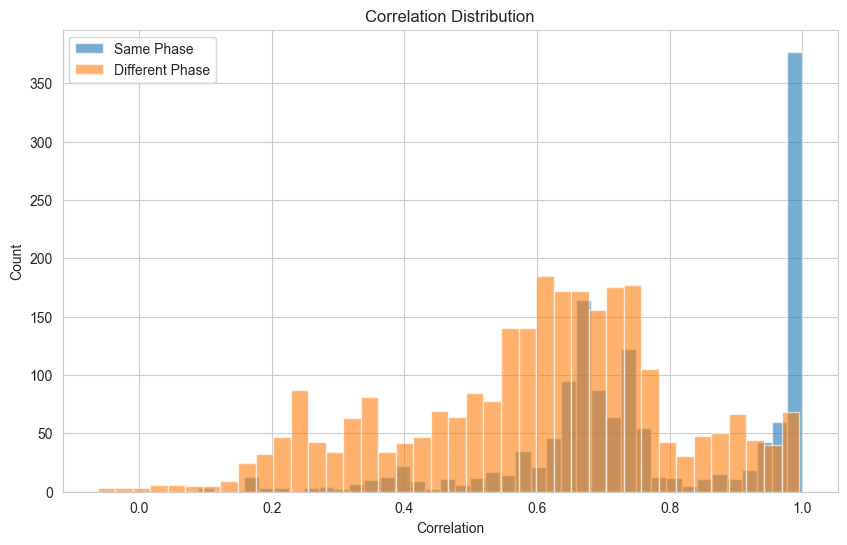

In [19]:
# =====================================================
# SAME PHASE vs DIFFERENT PHASE
# =====================================================

same_phase = []
different_phase = []

phase_lookup = dict(
    zip(
        phase_df.load_name,
        phase_df.true_phase
    )
)

loads = list(voltage_corr.columns)

for i in range(len(loads)):
    for j in range(i+1, len(loads)):

        c = voltage_corr.iloc[i,j]

        if phase_lookup[loads[i]] == phase_lookup[loads[j]]:
            same_phase.append(c)
        else:
            different_phase.append(c)

plt.figure(figsize=(10,6))

plt.hist(
    same_phase,
    bins=40,
    alpha=0.6,
    label="Same Phase"
)

plt.hist(
    different_phase,
    bins=40,
    alpha=0.6,
    label="Different Phase"
)

plt.xlabel("Correlation")

plt.ylabel("Count")

plt.title(
    "Correlation Distribution"
)

plt.legend()

plt.show()

PCA

Reduce:
35040 voltage samples
to
2 dimensions
for visualization.


Phase B:
Very distinct
Mostly located in the lower region.
Phase A:
Mostly upper region
Phase C:
Between A and B

PCA reveals noticeable clustering of phase labels in the reduced feature space. Although some overlap remains, the observed separation indicates that voltage measurements contain latent structures associated with phase connectivity.


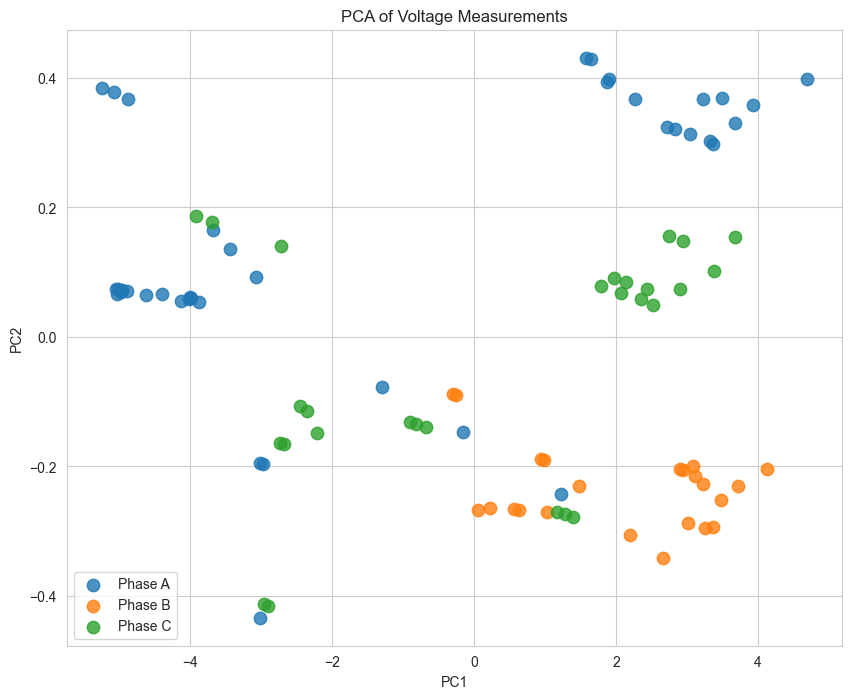

In [20]:
# =====================================================
# PCA VISUALIZATION
# =====================================================

from sklearn.decomposition import PCA

X = voltage_df.T.values

y = phase_df["true_phase"]

pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(X)

plt.figure(figsize=(10,8))

for phase in ["A","B","C"]:

    idx = y == phase

    plt.scatter(
        X_pca[idx,0],
        X_pca[idx,1],
        s=80,
        alpha=0.8,
        label=f"Phase {phase}"
    )

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title(
    "PCA of Voltage Measurements"
)

plt.legend()

plt.grid(True)

plt.show()

t-SNE Visualization

t-SNE captures nonlinear structure.
Phase B:
Forms a very clean trajectory
Phase A:
Mostly occupies a different region
Phase C:
Between A and B

This is exactly what we want before applying GNNs.
The classes are:
Not perfectly separable
but definitely not random.

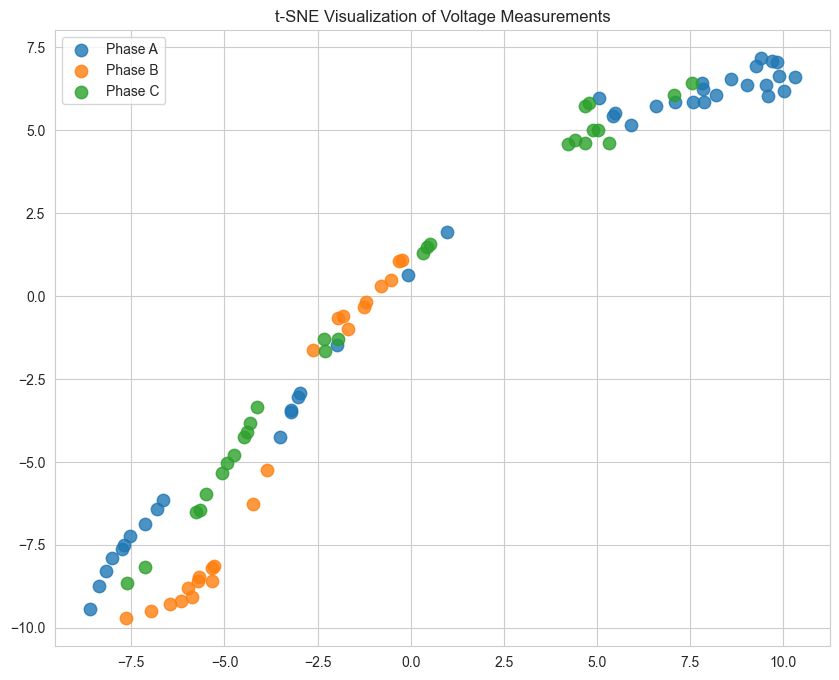

In [22]:
# =====================================================
# TSNE VISUALIZATION
# =====================================================

from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=20,
    random_state=42
)

X_tsne = tsne.fit_transform(X)

plt.figure(figsize=(10,8))

for phase in ["A","B","C"]:

    idx = y == phase

    plt.scatter(
        X_tsne[idx,0],
        X_tsne[idx,1],
        s=80,
        alpha=0.8,
        label=f"Phase {phase}"
    )

plt.title(
    "t-SNE Visualization of Voltage Measurements"
)

plt.legend()

plt.grid(True)

plt.show()

Hierarchical Clustering

This is the first true phase-identification baseline.

In [23]:
# =====================================================
# HIERARCHICAL CLUSTERING
# =====================================================

from sklearn.cluster import AgglomerativeClustering

cluster_model = AgglomerativeClustering(
    n_clusters=3
)

pred_clusters = cluster_model.fit_predict(X)

print(pred_clusters[:20])

[0 2 0 0 0 0 0 1 1 2 0 0 1 1 0 1 1 1 1 1]


In [24]:
# =====================================================
# CLUSTER COUNTS
# =====================================================

pd.Series(
    pred_clusters
).value_counts().sort_index()

0    28
1    32
2    31
Name: count, dtype: int64

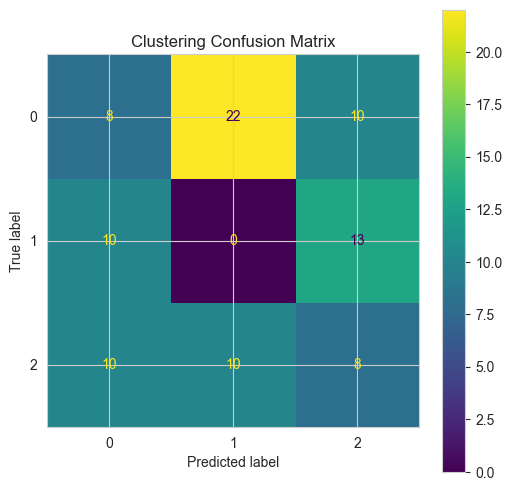

In [25]:
# =====================================================
# CONFUSION MATRIX
# =====================================================

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

phase_map = {
    "A":0,
    "B":1,
    "C":2
}

y_true = y.map(
    phase_map
)

cm = confusion_matrix(
    y_true,
    pred_clusters
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

fig, ax = plt.subplots(
    figsize=(6,6)
)

disp.plot(ax=ax)

plt.title(
    "Clustering Confusion Matrix"
)

plt.show()

In [26]:
# =====================================================
# SELECT 3 METERS FROM EACH PHASE
# =====================================================

phaseA = phase_df[
    phase_df["true_phase"] == "A"
]["load_name"].tolist()[:3]

phaseB = phase_df[
    phase_df["true_phase"] == "B"
]["load_name"].tolist()[:3]

phaseC = phase_df[
    phase_df["true_phase"] == "C"
]["load_name"].tolist()[:3]

print("Phase A:", phaseA)
print("Phase B:", phaseB)
print("Phase C:", phaseC)

Phase A: ['S1a', 'S7a', 'S9a']
Phase B: ['S2b', 'S12b', 'S22b']
Phase C: ['S4c', 'S5c', 'S6c']


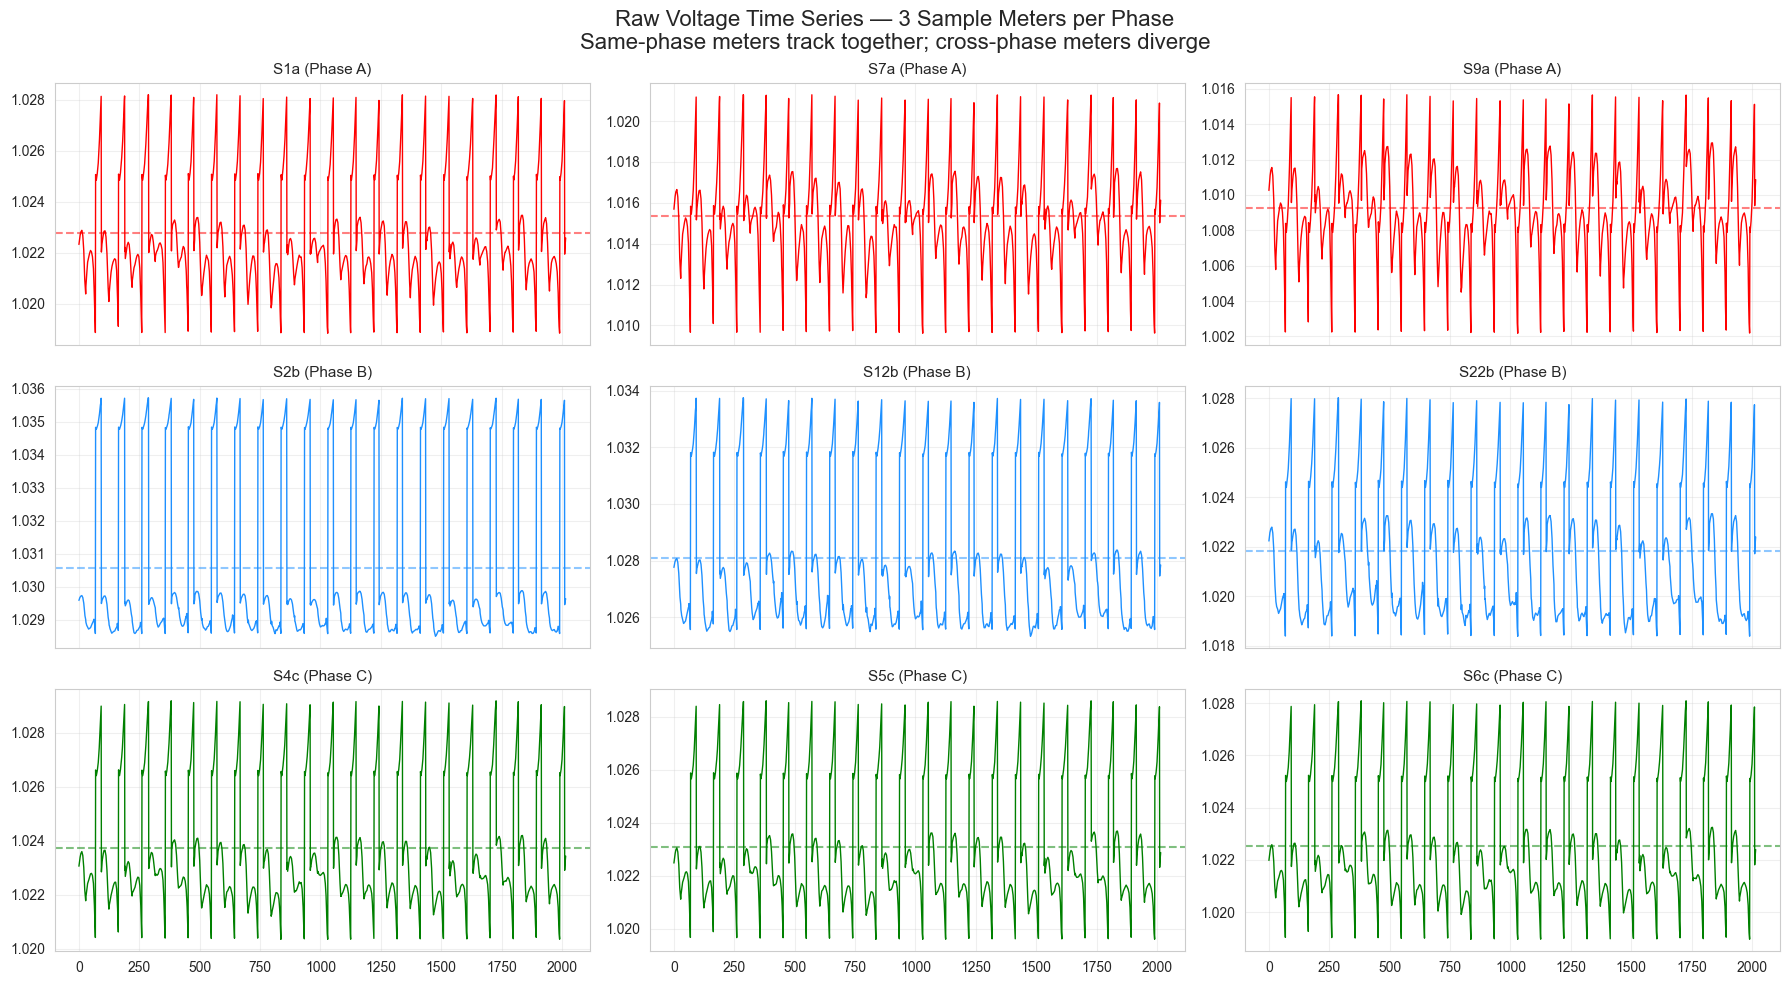

In [ ]:
# =====================================================
# 3 METERS PER PHASE
# =====================================================

phaseA = ["S1a","S7a","S9a"]
phaseB = ["S2b","S12b","S22b"]
phaseC = ["S4c","S5c","S6c"]

fig, axes = plt.subplots(
    3,
    3,
    figsize=(18,10),
    sharex=True
)

groups = [
    (phaseA,"A","red"),
    (phaseB,"B","dodgerblue"),
    (phaseC,"C","green")
]

for r,(meters,phase,color) in enumerate(groups):

    for c,meter in enumerate(meters):

        ax = axes[r,c]

        # weekly subset
        signal = voltage_df[meter][:2016]

        ax.plot(
            signal,
            color=color,
            linewidth=1
        )

        ax.axhline(
            signal.mean(),
            linestyle="--",
            alpha=0.5,
            color=color
        )

        ax.set_title(
            f"{meter} (Phase {phase})",
            fontsize=11
        )

        ax.grid(alpha=0.3)

plt.suptitle(
    "Raw Voltage Time Series — 3 Sample Meters per Phase\nSame-phase meters track together; cross-phase meters diverge",
    fontsize=16
)

plt.tight_layout()

plt.show()

In [ ]:
# ============================================
# BUILD LOAD NAMES + PHASE LIST
# ============================================

load_names = phase_df["load_name"].tolist()

phases = phase_df["true_phase"].tolist()

print(load_names[:5])
print(phases[:5])
print("Loads:", len(load_names))

['S1a', 'S2b', 'S4c', 'S5c', 'S6c']
['A', 'B', 'C', 'C', 'C']
Loads: 91


In [31]:
# ==========================================================
# LOAD GRAPH OBJECT
# ==========================================================

import torch

data = torch.load(
    r"D:\Phase_Identification_Project\data\ieee123_pyg_graph.pt",
    weights_only=False
)

print(data)
print("Nodes:", data.num_nodes)
print("Edge Index Shape:", data.edge_index.shape)

Data(x=[91, 20], edge_index=[2, 426], y=[91], train_mask=[91], val_mask=[91], test_mask=[91])
Nodes: 91
Edge Index Shape: torch.Size([2, 426])


Nodes=91  Edges=213


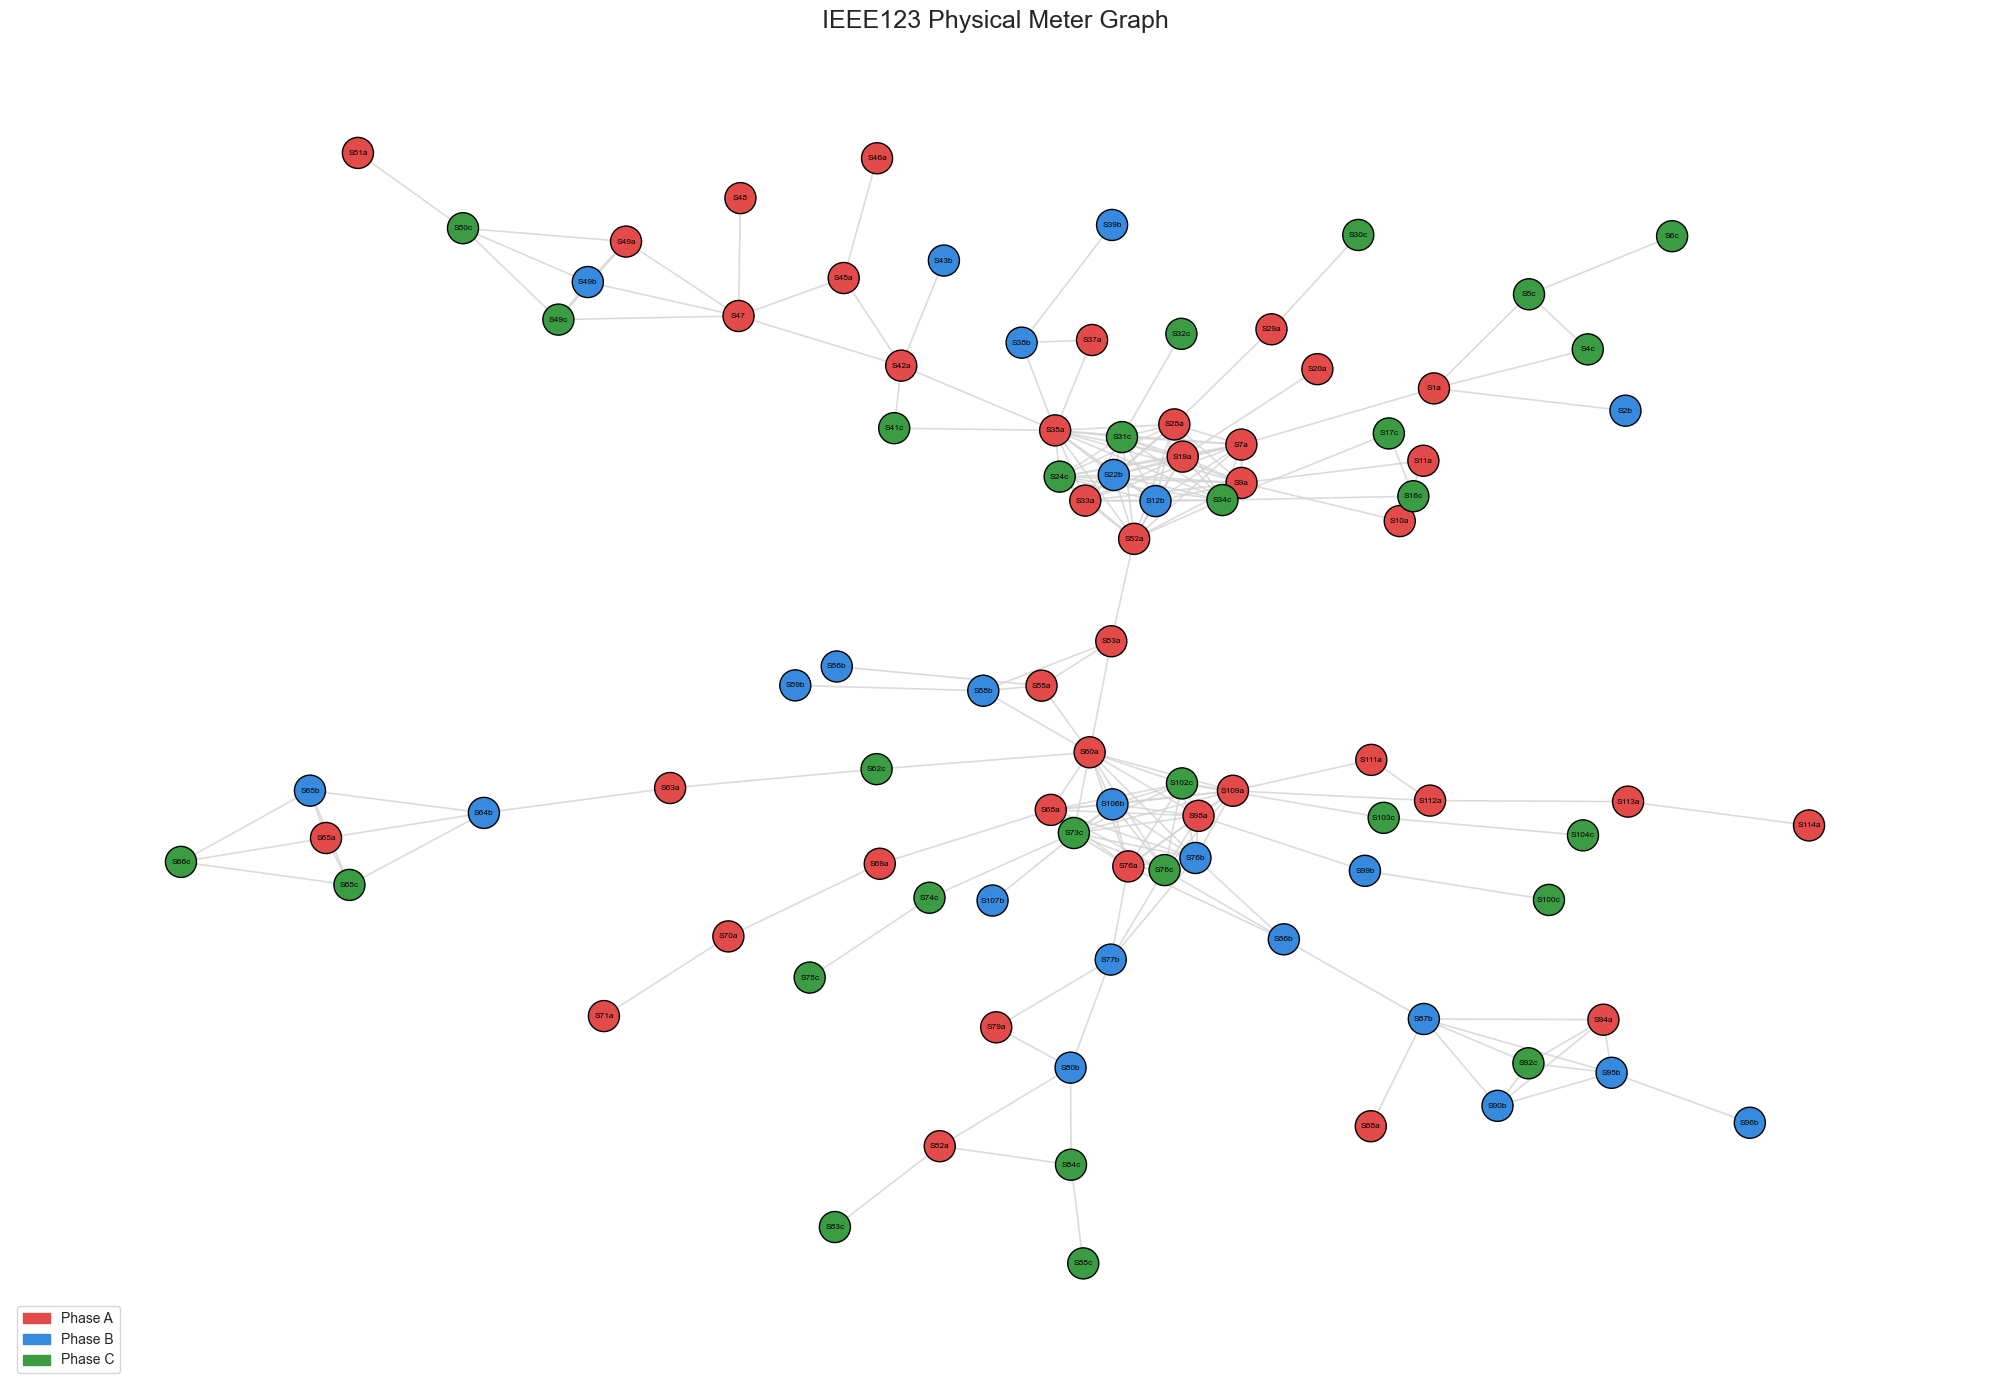

In [32]:
# ==========================================================
# FIGURE 1
# CLEAN PHYSICAL FEEDER GRAPH
# ==========================================================

import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

edge_index_np = data.edge_index.numpy()

G = nx.Graph()

G.add_nodes_from(range(data.num_nodes))

for i in range(edge_index_np.shape[1] // 2):
    G.add_edge(
        int(edge_index_np[0, i]),
        int(edge_index_np[1, i])
    )

print(
    f"Nodes={G.number_of_nodes()}  "
    f"Edges={G.number_of_edges()}"
)

# ----------------------------------
# Layout
# ----------------------------------

pos = nx.kamada_kawai_layout(
    G,
    scale=15
)

# ----------------------------------
# Phase Colors
# ----------------------------------

PHASE_COLORS = {
    'A':'#E24B4A',
    'B':'#378ADD',
    'C':'#3B9C44'
}

node_colors = [
    PHASE_COLORS[p]
    for p in phases
]

# ----------------------------------
# Plot
# ----------------------------------

plt.figure(figsize=(20,14))

nx.draw_networkx_edges(
    G,
    pos,
    edge_color='lightgray',
    width=1.2,
    alpha=0.8
)

nx.draw_networkx_nodes(
    G,
    pos,
    node_color=node_colors,
    node_size=500,
    edgecolors='black',
    linewidths=1
)

labels = {
    i: load_names[i]
    for i in range(data.num_nodes)
}

nx.draw_networkx_labels(
    G,
    pos,
    labels=labels,
    font_size=6
)

legend_elements = [
    mpatches.Patch(
        color='#E24B4A',
        label='Phase A'
    ),
    mpatches.Patch(
        color='#378ADD',
        label='Phase B'
    ),
    mpatches.Patch(
        color='#3B9C44',
        label='Phase C'
    )
]

plt.legend(
    handles=legend_elements,
    loc='lower left'
)

plt.title(
    "IEEE123 Physical Meter Graph",
    fontsize=18
)

plt.axis("off")

plt.tight_layout()

plt.show()

What it shows
Each node = one smart meter/load.
Gray edges = feeder connectivity.
Graph structure follows the actual IEEE123 topology.
Observation:
Several feeder branches are visible.
Central junctions are visible.
Radial structure is preserved.
Labels are readable.


This figure represents the physical topology of the IEEE 123-bus feeder. Each node corresponds to a smart meter, and edges represent electrical connectivity. Node colors indicate the ground-truth phase labels used for supervised learning. The graph demonstrates the radial structure of the distribution network and serves as the base topology for graph-based phase identification.

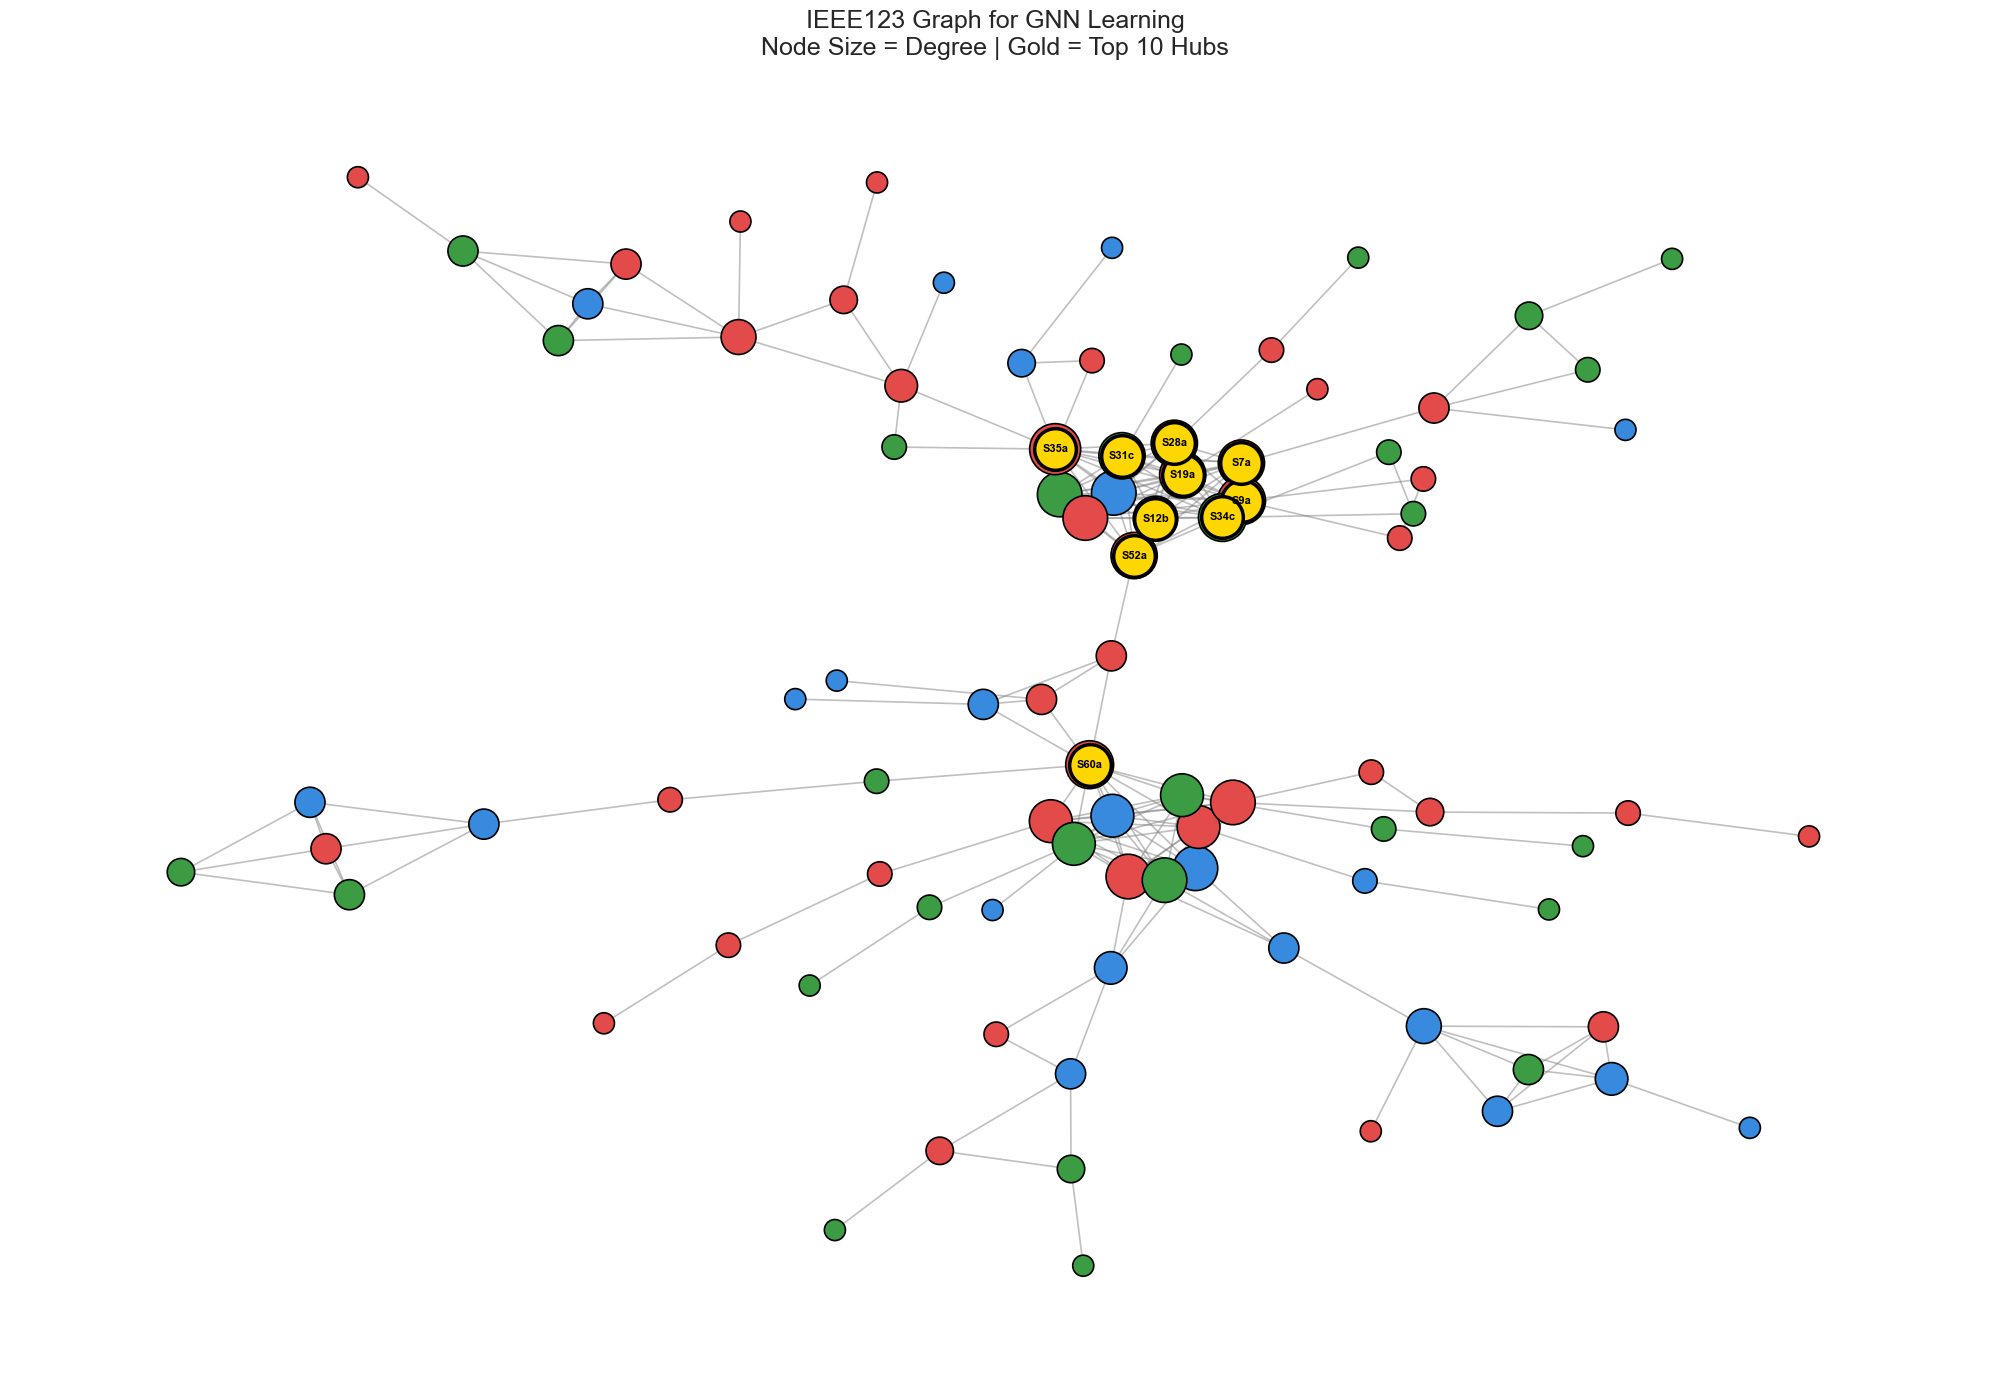

In [33]:
# ==========================================================
# FIGURE 2
# DEGREE-AWARE GNN GRAPH
# ==========================================================

degrees = dict(G.degree())

node_sizes = [
    150 + degrees[n]*80
    for n in G.nodes()
]

# Top 10 hubs only

top_nodes = sorted(
    degrees,
    key=degrees.get,
    reverse=True
)[:10]

labels = {
    n: load_names[n]
    for n in top_nodes
}

plt.figure(figsize=(20,14))

nx.draw_networkx_edges(
    G,
    pos,
    edge_color='gray',
    width=1.2,
    alpha=0.5
)

nx.draw_networkx_nodes(
    G,
    pos,
    node_color=node_colors,
    node_size=node_sizes,
    edgecolors='black',
    linewidths=1.2
)

# Highlight hubs

nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=top_nodes,
    node_color='gold',
    edgecolors='black',
    linewidths=2.5,
    node_size=900
)

nx.draw_networkx_labels(
    G,
    pos,
    labels=labels,
    font_size=8,
    font_weight='bold'
)

plt.title(
    "IEEE123 Graph for GNN Learning\n"
    "Node Size = Degree | Gold = Top 10 Hubs",
    fontsize=18
)

plt.axis("off")

plt.tight_layout()

plt.show()

What it shows
Same feeder graph.
Node size = degree.
Gold nodes = highest-degree hubs.
Observation:
The hubs are now clearly visible:
S13a
S28a
S31c
S52a
S60a
...
These are likely junction points where information propagates to many neighbors.

This graph highlights the structural importance of individual nodes. Node size is proportional to graph degree, while gold nodes represent the top 10 highest-degree hubs. These hubs play an important role during graph message passing because they aggregate information from multiple neighboring meters.

Correlation Graph: Nodes=91 Edges=462


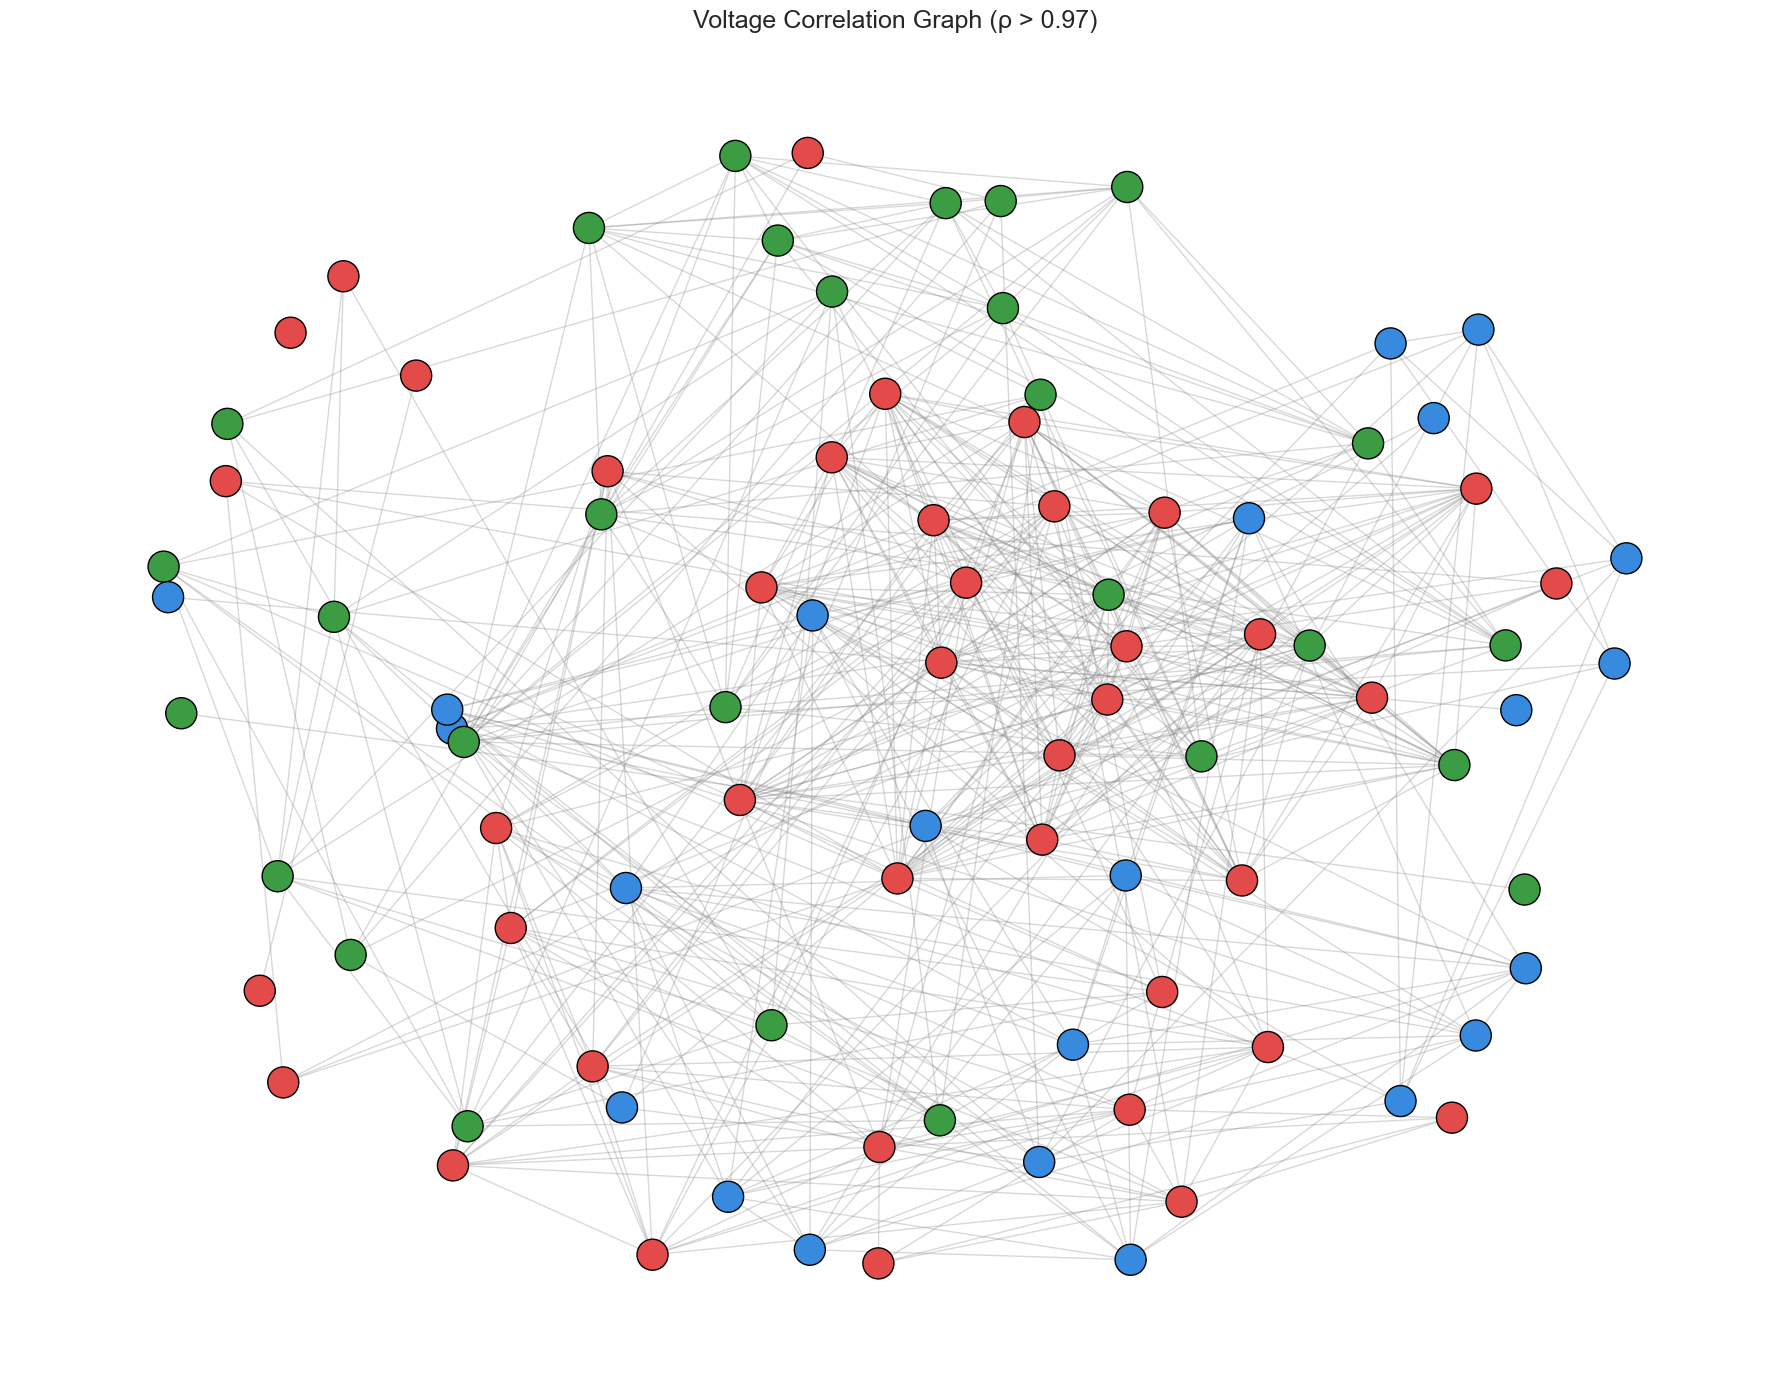

In [34]:
# ==========================================================
# FIGURE 3
# VOLTAGE CORRELATION GRAPH
# ==========================================================

corr = voltage_df.corr()

corr_threshold = 0.97
G_corr = nx.Graph()

for i in range(len(load_names)):
    G_corr.add_node(i)

for i in range(len(load_names)):
    for j in range(i+1,len(load_names)):

        if corr.iloc[i,j] > corr_threshold:

            G_corr.add_edge(i,j)

print(
    f"Correlation Graph:"
    f" Nodes={G_corr.number_of_nodes()}"
    f" Edges={G_corr.number_of_edges()}"
)

# ----------------------------------
# Layout
# ----------------------------------

pos_corr = nx.spring_layout(
    G_corr,
    seed=42,
    k=1.5
)

# ----------------------------------
# Plot
# ----------------------------------

plt.figure(figsize=(18,14))

nx.draw_networkx_edges(
    G_corr,
    pos_corr,
    alpha=0.3,
    edge_color='gray'
)

nx.draw_networkx_nodes(
    G_corr,
    pos_corr,
    node_color=node_colors,
    node_size=500,
    edgecolors='black'
)

plt.title(
    f"Voltage Correlation Graph (ρ > {corr_threshold})",
    fontsize=18
)

plt.axis("off")

plt.tight_layout()

plt.show()

Correlation > 0.97
Slightly fewer edges.
The voltage measurements are highly correlated across the entire feeder.
So:
Many loads experience similar voltage behavior
even when they belong to different phases.

This is why:
Simple correlation methods do not perfectly identify phases.
More advanced methods (PCA, clustering, GCN, GraphSAGE, GAT) are needed.

In [ ]:
voltage_df
phase_df

,load_name,true_phase
0,S1a,A
1,S2b,B
2,S4c,C
3,S5c,C
4,S6c,C
...,...,...
86,S109a,A
87,S111a,A
88,S112a,A
89,S113a,A


===== CORRELATION STATISTICS =====
Same-phase mean correlation: 0.7657
Different-phase mean correlation: 0.5979
Same-phase pairs: 1411
Different-phase pairs: 2684


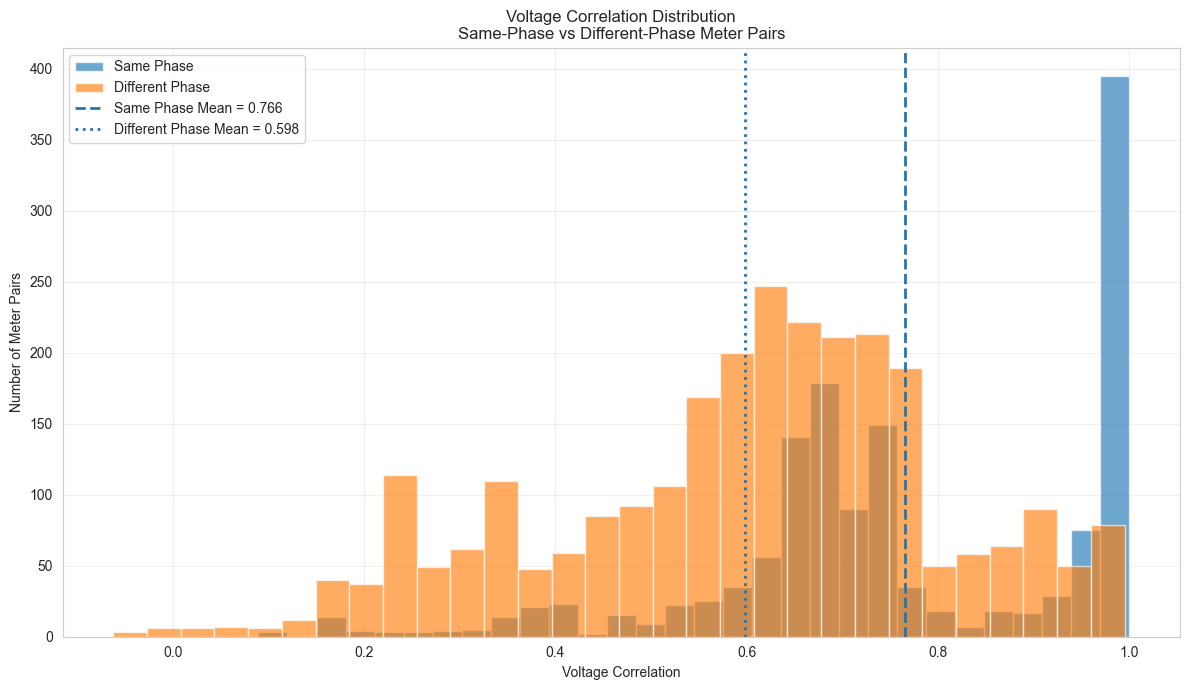

In [35]:
# ==========================================================
# SAME-PHASE vs DIFFERENT-PHASE CORRELATION DISTRIBUTION
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt

# Correlation matrix
corr_matrix = voltage_df.corr()

same_phase_corr = []
different_phase_corr = []

load_names = phase_df["load_name"].tolist()
phase_lookup = dict(
    zip(
        phase_df["load_name"],
        phase_df["true_phase"]
    )
)

# ----------------------------------------------------------
# Compare every pair of meters
# ----------------------------------------------------------

for i in range(len(load_names)):

    for j in range(i + 1, len(load_names)):

        meter1 = load_names[i]
        meter2 = load_names[j]

        corr_value = corr_matrix.loc[meter1, meter2]

        if phase_lookup[meter1] == phase_lookup[meter2]:

            same_phase_corr.append(corr_value)

        else:

            different_phase_corr.append(corr_value)

# ----------------------------------------------------------
# Summary statistics
# ----------------------------------------------------------

print("===== CORRELATION STATISTICS =====")

print(
    f"Same-phase mean correlation: "
    f"{np.mean(same_phase_corr):.4f}"
)

print(
    f"Different-phase mean correlation: "
    f"{np.mean(different_phase_corr):.4f}"
)

print(
    f"Same-phase pairs: "
    f"{len(same_phase_corr)}"
)

print(
    f"Different-phase pairs: "
    f"{len(different_phase_corr)}"
)

# ----------------------------------------------------------
# Plot
# ----------------------------------------------------------

plt.figure(figsize=(12,7))

plt.hist(
    same_phase_corr,
    bins=30,
    alpha=0.65,
    label="Same Phase",
    density=False
)

plt.hist(
    different_phase_corr,
    bins=30,
    alpha=0.65,
    label="Different Phase",
    density=False
)

plt.axvline(
    np.mean(same_phase_corr),
    linestyle="--",
    linewidth=2,
    label=f"Same Phase Mean = {np.mean(same_phase_corr):.3f}"
)

plt.axvline(
    np.mean(different_phase_corr),
    linestyle=":",
    linewidth=2,
    label=f"Different Phase Mean = {np.mean(different_phase_corr):.3f}"
)

plt.xlabel("Voltage Correlation")

plt.ylabel("Number of Meter Pairs")

plt.title(
    "Voltage Correlation Distribution\n"
    "Same-Phase vs Different-Phase Meter Pairs"
)

plt.legend()

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()

The distribution of voltage correlations was analyzed for all meter pairs. Meters belonging to the same phase exhibit significantly higher correlation values than meters belonging to different phases. The average same-phase correlation was 0.766, compared to 0.598 for different-phase pairs, resulting in a correlation separation of 0.168. This demonstrates that voltage time-series measurements contain phase-dependent information and supports the use of correlation-based and graph-based approaches for phase identification.

The blue distribution (same phase):
shifted toward higher correlations
Many same-phase pairs are clustered around:
0.7 – 1.0
and a large spike appears near:
1.0
which means some meters on the same phase have extremely similar voltage behavior.
The orange distribution (different phase):
shifted left
with many values between:
0.3 – 0.8
This indicates lower similarity between different-phase meters.

In [36]:
print(
    "\nCorrelation Separation:",
    np.mean(same_phase_corr) -
    np.mean(different_phase_corr)
)


Correlation Separation: 0.16780561631622415


PHASE IDENTIFICATION BASELINE
(Agglomerative Clustering) using PCA results

Voltage Data
      ↓
Detrending
      ↓
Correlation Matrix
      ↓
Distance Matrix
      ↓
Agglomerative Clustering (3 groups)
      ↓
Map clusters → A/B/C
      ↓
Accuracy
      ↓
Confusion Matrix

In [40]:
print(type(X_pca))
print(X_pca[:5])

<class 'numpy.ndarray'>
[[ 1.22057543 -0.24181411]
 [ 2.66187409 -0.34067741]
 [ 1.39519127 -0.27790773]
 [ 1.27532271 -0.27362603]
 [ 1.1711056  -0.26993142]]


In [41]:
    print(phase_df.head())

  load_name true_phase
0       S1a          A
1       S2b          B
2       S4c          C
3       S5c          C
4       S6c          C


In [42]:
from sklearn.cluster import AgglomerativeClustering
import numpy as np

pca_cluster = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"
)

pca_labels = pca_cluster.fit_predict(X_pca)

print("Cluster Counts:")
print(np.bincount(pca_labels))

Cluster Counts:
[32 27 32]


In [43]:
## Majority Vote Mapping
from collections import Counter

true_phases = phase_df["true_phase"].values

cluster_to_phase = {}

for cluster in np.unique(pca_labels):

    members = true_phases[pca_labels == cluster]

    majority_phase = Counter(members).most_common(1)[0][0]

    cluster_to_phase[cluster] = majority_phase

print("Cluster → Phase Mapping")
print(cluster_to_phase)

Cluster → Phase Mapping
{np.int64(0): 'A', np.int64(1): 'C', np.int64(2): 'B'}


In [44]:
## Generate Predictions
pred_phases = np.array([
    cluster_to_phase[c]
    for c in pca_labels
])

print(pred_phases[:10])

['C' 'B' 'C' 'C' 'C' 'C' 'C' 'A' 'A' 'B']


In [45]:
## Accuracy
from sklearn.metrics import accuracy_score

acc = accuracy_score(
    true_phases,
    pred_phases
)

print(f"Baseline Accuracy = {acc:.4f}")

Baseline Accuracy = 0.4945


In [46]:
## Classification Report
from sklearn.metrics import classification_report

print(
    classification_report(
        true_phases,
        pred_phases
    )
)

              precision    recall  f1-score   support

           A       0.69      0.55      0.61        40
           B       0.41      0.57      0.47        23
           C       0.37      0.36      0.36        28

    accuracy                           0.49        91
   macro avg       0.49      0.49      0.48        91
weighted avg       0.52      0.49      0.50        91



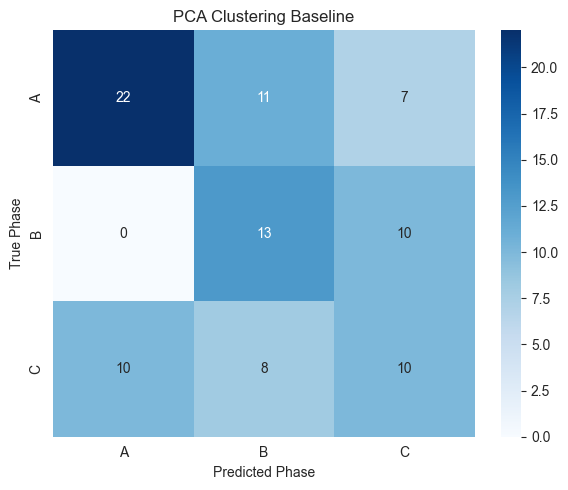

In [47]:
## Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    true_phases,
    pred_phases,
    labels=["A","B","C"]
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["A","B","C"],
    yticklabels=["A","B","C"]
)

plt.xlabel("Predicted Phase")
plt.ylabel("True Phase")
plt.title("PCA Clustering Baseline")

plt.tight_layout()
plt.show()

In [ ]:
## Correlation Clustering

features = np.abs(voltage_corr.values)
linkage = "ward"
print(features.shape)

(91, 91)


In [75]:
from sklearn.cluster import AgglomerativeClustering

AgglomerativeClustering(
    n_clusters=3,
    linkage="average"
)
cluster_labels = cluster_model.fit_predict(features)

print("Cluster Counts:")
print(np.bincount(cluster_labels))

Cluster Counts:
[55 22 14]


In [76]:
from collections import Counter

true_phases = phase_df["true_phase"].values

cluster_to_phase = {}

for cluster in np.unique(cluster_labels):

    members = true_phases[
        cluster_labels == cluster
    ]

    majority_phase = Counter(
        members
    ).most_common(1)[0][0]

    cluster_to_phase[cluster] = majority_phase

print(cluster_to_phase)

{np.int64(0): 'C', np.int64(1): 'A', np.int64(2): 'B'}


In [77]:
pred_phases = np.array([
    cluster_to_phase[c]
    for c in cluster_labels
])

In [78]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(
    true_phases,
    pred_phases
)

print(
    f"Correlation Baseline Accuracy = {acc:.4f}"
)

Correlation Baseline Accuracy = 0.5824


In [79]:
from sklearn.metrics import classification_report

print(
    classification_report(
        true_phases,
        pred_phases
    )
)

              precision    recall  f1-score   support

           A       0.86      0.47      0.61        40
           B       0.79      0.48      0.59        23
           C       0.42      0.82      0.55        28

    accuracy                           0.58        91
   macro avg       0.69      0.59      0.59        91
weighted avg       0.71      0.58      0.59        91



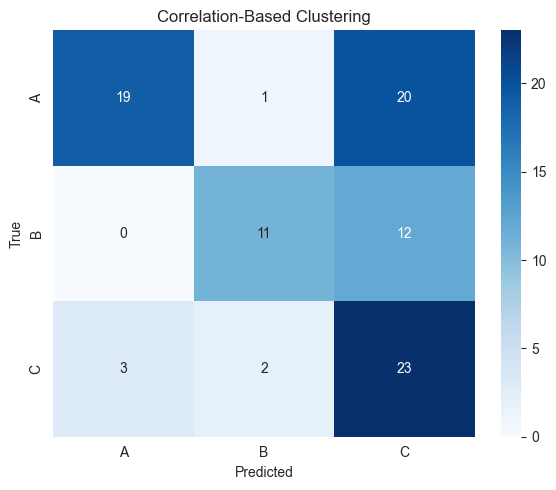

In [80]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    true_phases,
    pred_phases,
    labels=["A","B","C"]
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["A","B","C"],
    yticklabels=["A","B","C"]
)

plt.xlabel("Predicted")
plt.ylabel("True")

plt.title(
    "Correlation-Based Clustering"
)

plt.tight_layout()
plt.show()

In [ ]:
## Random Forest (Supervised ML (5-Fold CV))

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X = voltage_df.T.values
y = phase_df["true_phase"].values

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)

pred = rf.predict(X_test)

print(
    "Accuracy:",
    accuracy_score(y_test, pred)
)

Accuracy: 0.9473684210526315


In [82]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

scores = cross_val_score(
    rf,
    X,
    y,
    cv=5
)

print("Fold Accuracies:")
print(scores)

print(
    "Mean Accuracy:",
    scores.mean()
)

Fold Accuracies:
[0.47368421 0.83333333 0.55555556 0.83333333 0.72222222]
Mean Accuracy: 0.6836257309941521


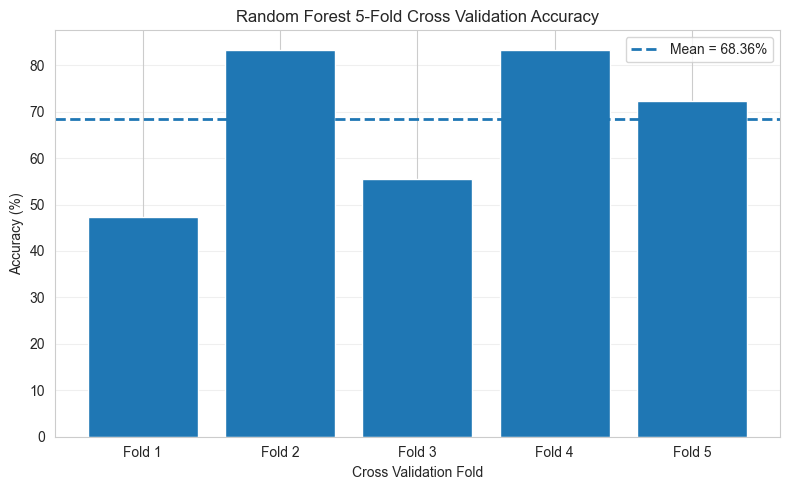

In [83]:
import matplotlib.pyplot as plt
import numpy as np

scores = np.array([
    0.47368421,
    0.83333333,
    0.55555556,
    0.83333333,
    0.72222222
])

plt.figure(figsize=(8,5))

plt.bar(
    [f"Fold {i}" for i in range(1,6)],
    scores * 100
)

plt.axhline(
    scores.mean()*100,
    linestyle="--",
    linewidth=2,
    label=f"Mean = {scores.mean()*100:.2f}%"
)

plt.ylabel("Accuracy (%)")
plt.xlabel("Cross Validation Fold")

plt.title(
    "Random Forest 5-Fold Cross Validation Accuracy"
)

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [84]:
print(f"Mean Accuracy: {scores.mean()*100:.2f}%")
print(f"Std Deviation: {scores.std()*100:.2f}%")

Mean Accuracy: 68.36%
Std Deviation: 14.61%
